In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

%load_ext autoreload
%autoreload 2

# 現在のフォルダの「1つ上の階層（../）」をシステムのパスに追加する
sys.path.append(os.path.abspath(".."))

#作成したモジュールをインポート
from src.data_prep import *


### データの読み込みとフィルタリング

In [15]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

%load_ext autoreload
%autoreload 2

# 現在のフォルダの「1つ上の階層（../）」をシステムのパスに追加する
sys.path.append(os.path.abspath(".."))

#作成したモジュールをインポート
from src.data_prep import *

df = load_trajectory_data()
df_clean_p = remove_flicker_noise(df, col='Preceding', threshold=50)
df_clean = remove_flicker_noise(df_clean_p, col='Lane_ID', threshold=50) 

# ① ペアID付与
df_with_pairs = give_pair_id(df_clean)

# ② モードID付与
df_with_mode = give_mode_id_with_pair_id(df_with_pairs, df)

# ③ 追従していない行を除外 追従している車両のみのデータが完成
df_valid = filter_valid_pairs(df_with_mode)

# ④ 車線フィルタ（Lanes 2, 3, 4のみ）
df_lane = filter_lane_with_pair_id(df_valid)

# ⑤ モードフィルタ
df_mode = filter_mode_with_pair_id(df_lane)

# ⑥ 追従時間フィルタ
df_duration = filter_duration_with_pair_id(df_mode)

# ⑧ カットオフウィンドウ
df_cutoff = apply_cutoff_with_pair_id(df_duration)

# ⑦ 加速度フィルタ
df_final = filter_acceleration_with_pair_id(df_cutoff).copy()


# 最終結果の確認
print(f"\n===最終結果===")
print(f"行数: {len(df_final):,}")
print(f"ペア数: {df_final['pair_id'].nunique():,}")
assign_and_count_pair_type_with_pair_id(df_final)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
(4566387, 19)
フリッカリング除去完了
補正されたブロック数: 1,395
行数: 4,566,387
フリッカリング除去完了
補正されたブロック数: 243
行数: 4,566,387
モードID別ペア数:
mode_id
1.0    11758
2.0      416
3.0      531
4.0       40
5.0      384
dtype: int64
フィルタ前の行数: 4,566,387
フィルタ後の行数: 4,361,142
除外された行数: 205,245

ペア数: 13,129
フィルタ前: 4,361,142行
フィルタ後: 2,338,121行
除外された行数: 2,023,021行

車線の分布:
Lane_ID
2.0    799894
3.0    689226
4.0    849001
Name: count, dtype: int64
フィルタ前のペア数: 5,443
フィルタ後のペア数: 5,375
除外されたペア数: 68

モードID別ペア数:
mode_id
1.0    4800
2.0     227
3.0     314
4.0      34
dtype: int64
フィルタ前のペア数: 5,375
フィルタ後のペア数: 1,577
除外されたペア数: 3,798

フィルタ前の行数: 2,335,579
フィルタ後の行数: 1,508,130
カットオフ前の行数: 1,508,130
カットオフ後の行数: 1,192,730
除外された行数: 315,400

カットオフ前のペア数: 1,577
カットオフ後のペア数: 1,577
閾値: 1.0 m/s² = 3.2808 feet/s²

フィルタ前の行数: 1,192,730
フィルタ後の行数: 895,533
除外された行数: 297,197

フィルタ前のペア数: 1,577
フィルタ後のペア数: 1,577

===最終結果===
行数: 895,533
ペア数: 1,577
追従ペア数:
pair_type
C-C    1456
C-T  

,Vehicle_ID,Frame_ID,Total_Frames,Global_Time,Local_X,Local_Y,Global_X,Global_Y,v_Length,v_Width,...,Preceding,Following,Space_Headway,Time_Headway,time_period,pair_id,leader_class,ego_class,mode_id,pair_type
100,11,157,864,1113433150600,15.236,130.989,6042830.240,2133199.574,17.3,8.4,...,1.0,0,43.76,5.83,1,13.0,2.0,2,1.0,C-C
101,11,158,864,1113433150700,15.212,131.739,6042830.123,2133200.315,17.3,8.4,...,1.0,0,44.06,5.87,1,13.0,2.0,2,1.0,C-C
102,11,159,864,1113433150800,15.188,132.489,6042830.006,2133201.056,17.3,8.4,...,1.0,0,44.36,5.91,1,13.0,2.0,2,1.0,C-C
103,11,160,864,1113433150900,15.163,133.239,6042829.889,2133201.797,17.3,8.4,...,1.0,0,44.66,5.95,1,13.0,2.0,2,1.0,C-C
104,11,161,864,1113433151000,15.139,133.990,6042829.772,2133202.539,17.3,8.4,...,1.0,0,44.96,5.99,1,13.0,2.0,2,1.0,C-C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1508023,3006,2950,828,1113437859900,42.358,1389.949,6042683.839,2134451.291,15.8,6.9,...,479.0,491,31.61,2.64,3,19256.0,2.0,2,1.0,C-C
1508024,3006,2951,828,1113437860000,42.352,1391.149,6042683.641,2134452.475,15.8,6.9,...,479.0,491,31.91,2.66,3,19256.0,2.0,2,1.0,C-C
1508025,3006,2952,828,1113437860100,42.345,1392.350,6042683.443,2134453.658,15.8,6.9,...,479.0,491,32.19,2.69,3,19256.0,2.0,2,1.0,C-C
1508026,3006,2953,828,1113437860200,42.340,1393.544,6042683.246,2134454.842,15.8,6.9,...,479.0,491,32.49,2.71,3,19256.0,2.0,2,1.0,C-C


### 異常な密度を検知して除外<br>
名目速度関数の推定では異常な密度をもつデータは除外する。<br>
マクロ密度を考える際には問題はないため、それ以降は推定時では除外したデータも推定された名目速度関数に従うと仮定して進める。<br>

車体が少なくとも4mあるとして、15feet=約4.5m　だから、お尻と頭の距離が0.5m以下のデータが3600件強ある。<br>



In [9]:
#密度を確認
FT_TO_M = 0.3048

# まず異常値の実態を確認
print("Space_Headway <= 0feet の行数:", (df_final['Space_Headway'] <= 0).sum())
print("Space_Headway <= 14feeet の行数:", (df_final['Space_Headway'] <= 14).sum())
print("Space_Headway <= 15feeet の行数:", (df_final['Space_Headway'] <= 15).sum())
print("Space_Headway(feet)の分布:")
print(df_final['Space_Headway'].describe())
print("\n下位1%の値:", df_final['Space_Headway'].quantile(0.01), "feet")

Space_Headway <= 0feet の行数: 0
Space_Headway <= 14feeet の行数: 2753
Space_Headway <= 15feeet の行数: 3689
Space_Headway(feet)の分布:
count    895533.000000
mean         44.226897
std          19.817101
min           0.010000
25%          30.320000
50%          39.820000
75%          52.880000
max         250.990000
Name: Space_Headway, dtype: float64

下位1%の値: 17.3 feet


spacing <= 4.5m の行を除外: 895,533 -> 892,162 (除外 3,371行)


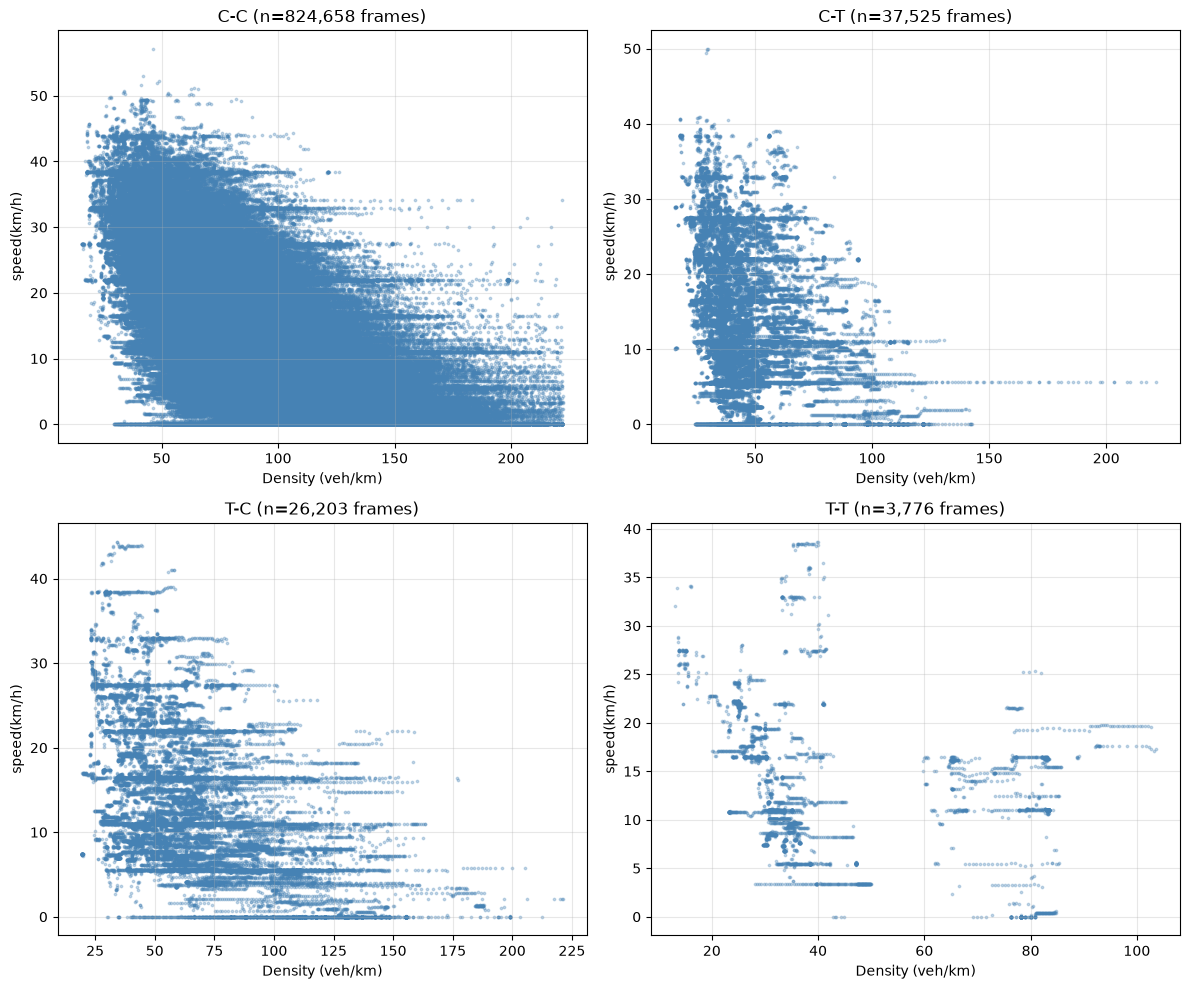

In [22]:
min_spacing_m = 4.5  # これ未満は「明らかにおかしい」として除外する閾値

df_fd = df_final.copy()
df_fd['spacing_m'] = df_fd['Space_Headway'] * FT_TO_M

before = len(df_fd)
df_fd = df_fd[df_fd['spacing_m'] > min_spacing_m]
after = len(df_fd)
print(f"spacing <= {min_spacing_m}m の行を除外: {before:,} -> {after:,} (除外 {before-after:,}行)")

df_fd['density_veh_km'] = 1000 / df_fd['spacing_m']
df_fd['speed_kmh'] = df_fd['v_Vel'] * FT_TO_M * 3.6
df_fd['flow_veh_h'] = df_fd['density_veh_km'] * df_fd['speed_kmh']


#除外後のペアタイプごとの密度速度分布を図示
pair_types = [1,2, 3, 4]
mode_map = {
    1: 'C-C',
    2: 'C-T',
    3: 'T-C',
    4: 'T-T'
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, pt in zip(axes.flat, pair_types):
    sub = df_fd[df_fd['mode_id'] == pt]
    ax.scatter(sub['density_veh_km'], sub['speed_kmh'], s=3, alpha=0.3, color='steelblue')
    ax.set_xlabel('Density (veh/km)')
    ax.set_ylabel('speed(km/h)')
    ax.set_title(f'{mode_map[pt]} (n={len(sub):,} frames)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 基本図を描くため、マクロ密度・平均速度の計算も導入

In [ ]:
import numpy as np
import pandas as pd

def compute_macroscopic_snapshots(df, lanes=(2, 3, 4), classes=(2, 3), snapshot_step_frames=5,
                                    L_m=None, n_lanes=None):
    """
    Algorithm 1 Step 2: 一定間隔(デフォルト5フレーム=0.5秒)でスナップショットを取り、
    マクロ密度(veh/km/lane)・平均速度(km/h)・流率(veh/h/lane)を計算する。

    df: 車線・車種で絞り込む前の全車両trajectoryデータ(関数内でlanes/classesに絞る)
    lanes: 対象車線
    classes: 対象車種(2=car, 3=truck)
    snapshot_step_frames: 何フレームおきにスナップショットを取るか
    L_m: 区間長(m)1,640feet = 1,640 * 0.3048 = 499.872mメタデータではこう書いているが、実際のデータのy座標の範囲から自動計算する 見えない加工の可能性を避けるために（カメラの画角で切られている部分があるとか）
    n_lanes: 車線数。3
    """
    FT_TO_M = 0.3048
    target = df[df['Lane_ID'].isin(lanes) & df['v_Class'].isin(classes)].copy()

    if L_m is None:
        L_m = (target['Local_Y'].max() - target['Local_Y'].min()) * FT_TO_M
    if n_lanes is None:
        n_lanes = len(lanes)
    L_km = L_m / 1000

    print(f"区間長: {L_m:.1f} m, 車線数: {n_lanes}")

    # time_periodごとに、snapshot_step_framesおきのGlobal_Timeだけ残す
    snapshot_mask = pd.Series(False, index=target.index)
    for tp, group in target.groupby('time_period'):
        times_sorted = np.sort(group['Global_Time'].unique())
        snapshot_times = set(times_sorted[::snapshot_step_frames])
        snapshot_mask.loc[group.index] = group['Global_Time'].isin(snapshot_times)

    snap_rows = target[snapshot_mask]

    agg = snap_rows.groupby(['time_period', 'Global_Time', 'v_Class']).agg(
        n_vehicles=('Vehicle_ID', 'size'),
        speed_kmh=('v_Vel', lambda s: (s * FT_TO_M * 3.6).mean())
    ).reset_index()

    agg['density_veh_km'] = agg['n_vehicles'] / (L_km * n_lanes)
    agg['flow_veh_h'] = agg['density_veh_km'] * agg['speed_kmh']

    return agg

#マクロ密度は、ミクロ密度がおかしくても問題ないため除外前データを使う
df_macro_density = compute_macroscopic_snapshots(df_final, lanes=(2, 3, 4), classes=(2, 3), snapshot_step_frames=5)


区間長: 473.9 m, 車線数: 3


### 基本図を描く

区間長: 545.8 m, 車線数: 3


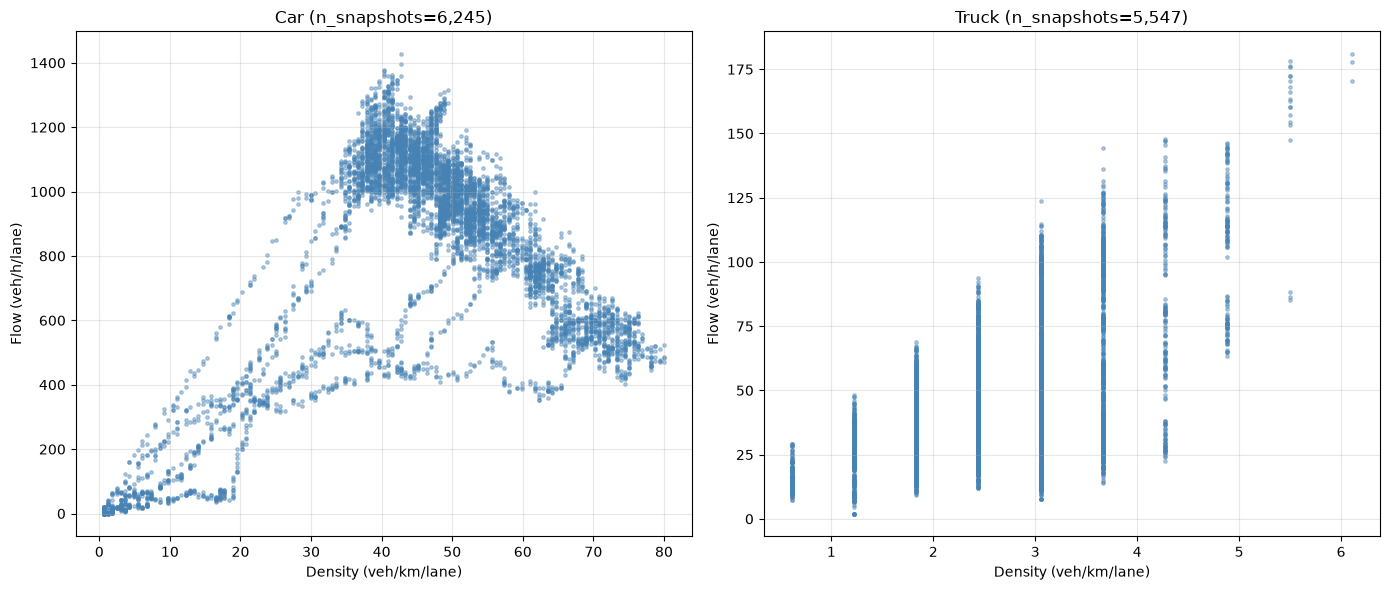

In [ ]:
import matplotlib.pyplot as plt

snapshots = compute_macroscopic_snapshots(df_clean, lanes=(2, 3, 4), classes=(2, 3), snapshot_step_frames=5)

class_labels = {2: 'Car', 3: 'Truck'}
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, cls in zip(axes, [2, 3]):
    sub = snapshots[snapshots['v_Class'] == cls]
    ax.scatter(sub['density_veh_km'], sub['flow_veh_h'], s=6, alpha=0.4, color='steelblue')
    ax.set_xlabel('Density (veh/km/lane)')
    ax.set_ylabel('Flow (veh/h/lane)')
    ax.set_title(f'{class_labels[cls]} (n_snapshots={len(sub):,})')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

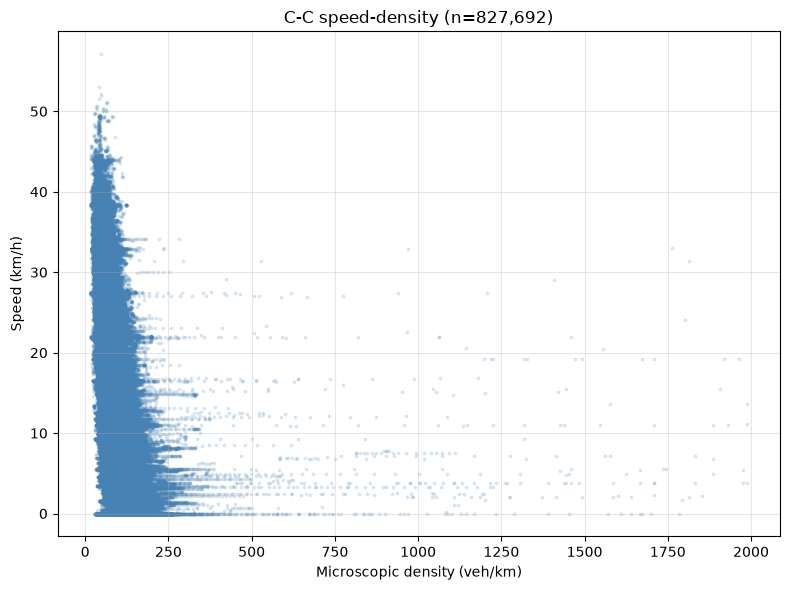

In [ ]:
import matplotlib.pyplot as plt

FT_TO_M = 0.3048
min_spacing_m = 0.5
df_final = assign_pair_type(df_final)
cc = df_final[df_final['pair_type'] == 'C-C'].copy()
cc['spacing_m'] = cc['Space_Headway'] * FT_TO_M
cc = cc[cc['spacing_m'] > min_spacing_m]
cc['density_veh_km'] = 1000 / cc['spacing_m']
cc['speed_kmh'] = cc['v_Vel'] * FT_TO_M * 3.6

plt.figure(figsize=(8, 6))
plt.scatter(cc['density_veh_km'], cc['speed_kmh'], s=3, alpha=0.15, color='steelblue')
plt.xlabel('Microscopic density (veh/km)')
plt.ylabel('Speed (km/h)')
plt.title(f'C-C speed-density (n={len(cc):,})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 各モードの基本図を描く

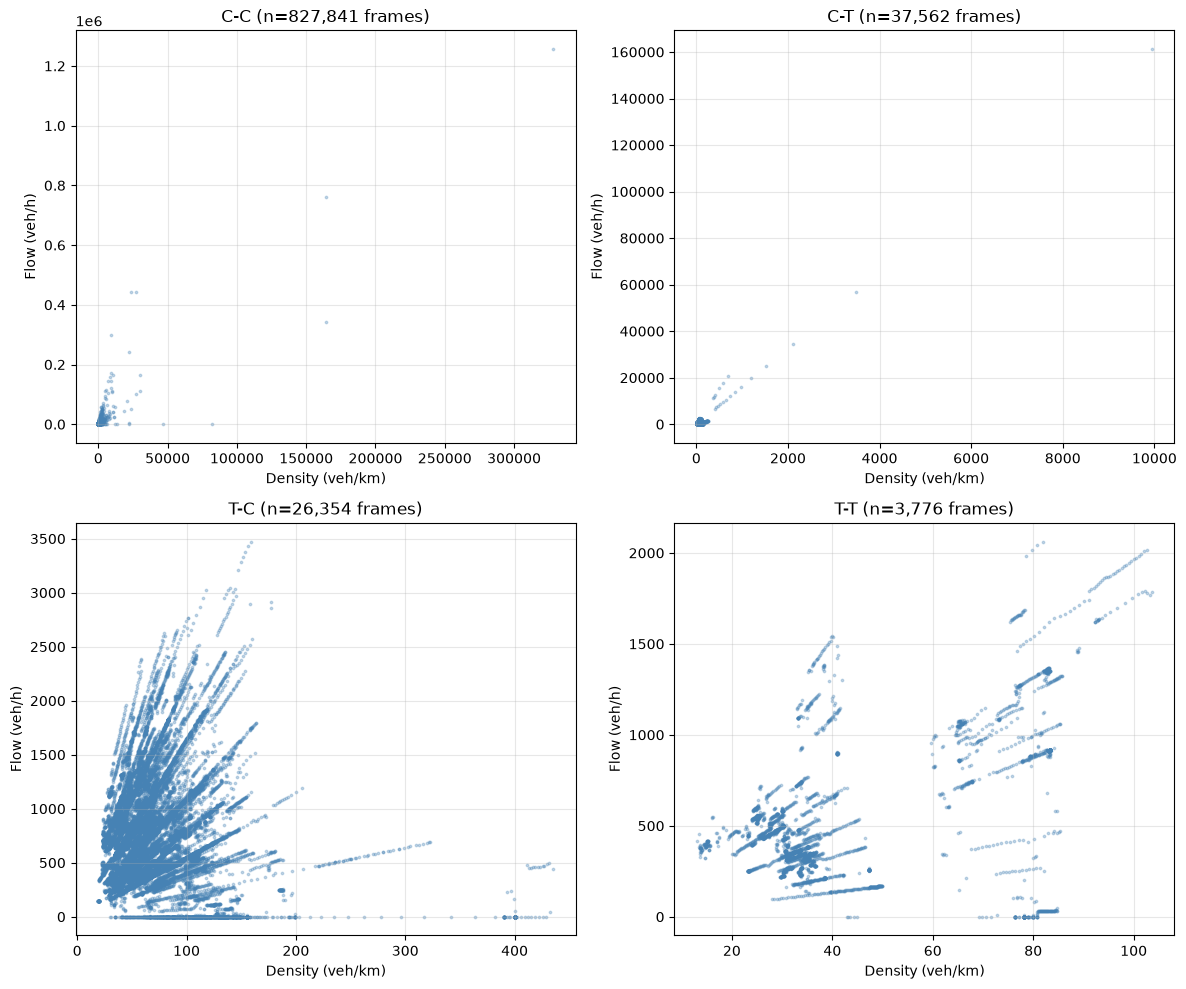

In [ ]:
import matplotlib.pyplot as plt

FT_TO_M = 0.3048

df_final = assign_pair_type(df_final)  # pair_type列がまだなければ付与

df_fd = df_final.copy()
df_fd['spacing_m'] = df_fd['Space_Headway'] * FT_TO_M          # 車間距離(m)
df_fd['density_veh_km'] = 1000 / df_fd['spacing_m']            # 密度(veh/km) = 1/spacing
df_fd['speed_kmh'] = df_fd['v_Vel'] * FT_TO_M * 3.6             # 速度(km/h)
df_fd['flow_veh_h'] = df_fd['density_veh_km'] * df_fd['speed_kmh']  # 流率(veh/h) = density * speed

pair_types = ['C-C', 'C-T', 'T-C', 'T-T']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, pt in zip(axes.flat, pair_types):
    sub = df_fd[df_fd['pair_type'] == pt]
    ax.scatter(sub['density_veh_km'], sub['flow_veh_h'], s=3, alpha=0.3, color='steelblue')
    ax.set_xlabel('Density (veh/km)')
    ax.set_ylabel('Flow (veh/h)')
    ax.set_title(f'{pt} (n={len(sub):,} frames)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 1-a.名目速度関数の推定

#### ミクロ密度の計算

In [ ]:
def calculate_micro_density(df, headway_col='Space_Headway', drop_invalid=True):
    """
    車間距離からミクロ密度を計算し、データフレームに追加する関数。
    ゼロ除算によって発生する inf（無限大）の処理も併せて行う。
    
    Parameters:
    df (pd.DataFrame): 処理対象のデータフレーム
    headway_col (str): 車間距離が格納されている列名（デフォルト: 'Space_Headway'）
    drop_invalid (bool): infやNaNになった行を削除するかどうか（デフォルト: True）
    
    Returns:
    pd.DataFrame: ミクロ密度が追加されたデータフレーム
    """
    # SettingWithCopyWarningを防ぐため安全にコピーを作成
    df_out = df.copy()
    
    # 1. 基本のミクロ密度計算（単位：vehicles / feet）
    df_out['Micro_density'] = 1 / df_out[headway_col]
    
    # 2. 論文に合わせたミクロ密度計算（単位：vpm = vehicles / mile）
    # 1マイル = 5280フィート なので、5280を割ることでマイルあたりの台数に変換
    df_out['Micro_density_vpm'] = 5280 / df_out[headway_col]
    
    # 3. ゼロ除算で発生した inf を NaN に置換
    df_out['Micro_density'] = df_out['Micro_density'].replace([np.inf, -np.inf], np.nan)
    df_out['Micro_density_vpm'] = df_out['Micro_density_vpm'].replace([np.inf, -np.inf], np.nan)
    
    # 4. 無効な値（NaN）を含む行を削除
    if drop_invalid:
        before_len = len(df_out)
        df_out = df_out.dropna(subset=['Micro_density', 'Micro_density_vpm'])
        after_len = len(df_out)
        dropped = before_len - after_len
        print(f"--- ミクロ密度計算 ---")
        print(f"無効な車間距離(0など)による除外: {dropped:,}行")
        print(f"計算後の行数: {after_len:,}行\n")
        
    return df_out

# 実行例（先ほどの df_final に対して適用）
df_density = calculate_micro_density(df_final)

# 結果の確認
display_cols = ['Vehicle_ID', 'Global_Time', 'v_Class', 'Preceding', 'Space_Headway', 'Micro_density', 'Micro_density_vpm']
print(df_density[display_cols].head())

--- ミクロ密度計算 ---
無効な車間距離(0など)による除外: 0行
計算後の行数: 879,140行

     Vehicle_ID    Global_Time  v_Class  Preceding  Space_Headway  \
100          11  1113433150600        2        1.0          43.76   
101          11  1113433150700        2        1.0          44.06   
102          11  1113433150800        2        1.0          44.36   
103          11  1113433150900        2        1.0          44.66   
104          11  1113433151000        2        1.0          44.96   

     Micro_density  Micro_density_vpm  
100       0.022852         120.658135  
101       0.022696         119.836586  
102       0.022543         119.026150  
103       0.022391         118.226601  
104       0.022242         117.437722  


#### 乗用車クラス

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import pygmo as pg


# 1. pygmo用 最適化問題（問題定義）クラス
class LogisticSpeedDensityProblem:
    def __init__(self, X, Y):
        """
        X: ミクロ密度 (Micro_density_vpm)
        Y: 観測速度 (v_Vel)
        """
        self.X = X.values if isinstance(X, pd.Series) else X
        self.Y = Y.values if isinstance(Y, pd.Series) else Y

    def fitness(self, x):
        """
        目的関数: L1ノルム損失 (MAEの和)
        x = [ub, uf, rhoc, theta1, theta2]
        """
        ub, uf, rhoc, theta1, theta2 = x
        
        # ロジスティック関数の計算
        # オーバーフローを防ぐためクリッピング
        exp_term = np.exp(np.clip((self.X - rhoc) / theta1, -100, 100))
        pred_speed = ub + (uf - ub) / ((1 + exp_term) ** theta2)
        
        # L1ノルム損失
        loss = np.sum(np.abs(self.Y - pred_speed))
        return [loss]

    def get_bounds(self):
        """
        パラメータの探索範囲 (Lower bounds, Upper bounds)
        論文等の物理的妥当性に基づく一般的な制約
        [ub, uf, rhoc, theta1, theta2]
        """
        lb = [0.0, 30.0, 10.0, 0.1, 0.1]     # 下限
        ub = [30.0, 90.0, 150.0, 50.0, 10.0] # 上限
        return (lb, ub)

# 2. パラメータ推定関数
def fit_logistic_model_isres(df, mode_id, mode_name):
    """
    指定されたmode_idのデータに対してISRESでパラメータを推定する関数
    """
    print(f"\n{'='*40}")
    print(f" モデル推定開始: {mode_name} (mode_id={mode_id})")
    print(f"{'='*40}")
    
    # 対象モードのデータ抽出 (NaNが含まれている場合は除外)
    df_mode = df[df['mode_id'] == mode_id].dropna(subset=['Micro_density_vpm', 'v_Vel'])
    
    if len(df_mode) == 0:
        print("エラー: 該当するデータが存在しません。")
        return None
        
    X = df_mode['Micro_density_vpm']
    Y = df_mode['v_Vel']
    
    # 70%の訓練セットと30%のテストセットに分割
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
    
    print(f"データ分割: 訓練データ {len(X_train)}行, テストデータ {len(X_test)}行")
    
    # pygmoの問題・アルゴリズム・ポピュレーションの定義
    prob = pg.problem(LogisticSpeedDensityProblem(X_train, Y_train))
    
    # ISRESアルゴリズムの定義 (gen=世代数)
    # ※収束が悪い場合は gen を増やしてください
    algo = pg.algorithm(pg.isres(gen=500))
    algo.set_verbosity(100) # 途中経過の出力
    
    # ポピュレーション（個体群）の初期化
    pop_size = 50
    pop = pg.population(prob, size=pop_size)
    
    # 進化（最適化）の実行
    print("ISRESアルゴリズムで最適化を実行中...")
    pop = algo.evolve(pop)
    
    # 最適パラメータの取得
    best_params = pop.champion_x
    ub, uf, rhoc, theta1, theta2 = best_params
    
    # テストセットでの評価 (MAE)
    exp_term_test = np.exp(np.clip((X_test - rhoc) / theta1, -100, 100))
    Y_pred_test = ub + (uf - ub) / ((1 + exp_term_test) ** theta2)
    test_mae = mean_absolute_error(Y_test, Y_pred_test)
    
    print("\n--- 推定結果 ---")
    print(f"u_b (平均走行速度)       : {ub:.4f} mph")
    print(f"u_f (自由流速度)         : {uf:.4f} mph")
    print(f"rho_c (臨界密度)         : {rhoc:.4f} vpm")
    print(f"theta_1 (スケールパラ)   : {theta1:.4f}")
    print(f"theta_2 (偏りパラ)       : {theta2:.4f}")
    print(f"テストデータ MAE         : {test_mae:.4f} mph")
    
    return {
        'mode_name': mode_name,
        'params': best_params,
        'test_mae': test_mae
    }

# 3. 実行部分
# C-C追従 (mode_id=1) の推定
results_cc = fit_logistic_model_isres(df_density, mode_id=1, mode_name="C-C 追従")

# C-T追従 (mode_id=2) の推定
results_ct = fit_logistic_model_isres(df_density, mode_id=2, mode_name="C-T 追従")

ImportError: The `scipy` install you are using seems to be broken, (extension modules cannot be imported), please try reinstalling.

In [ ]:
import nlopt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

def fit_logistic_model_nlopt_isres(df, mode_id, mode_name):
    # 速度変換係数 (1 mph = 1.4667 ft/s)
    FT_S_TO_MPH = 1.4667
    
    print(f"\n{'='*40}")
    
    print(f" モデル推定開始 (ISRES): {mode_name} (mode_id={mode_id})")
    print(f"{'='*40}")
    
    # 1. データの抽出と単位変換 (ft/s -> mph)
    df_mode = df[df['mode_id'] == mode_id].dropna(subset=['Micro_density_vpm', 'v_Vel']).copy()
    if len(df_mode) == 0:
        print("エラー: 該当するデータが存在しません。")
        return None
        
    df_mode['v_Vel_mph'] = df_mode['v_Vel'] / FT_S_TO_MPH
    
    X = df_mode['Micro_density_vpm'].values
    Y = df_mode['v_Vel_mph'].values  # 変換後の速度を使用
    
    # 70:30で分割
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
    
    # 2. 目的関数
    def objective(x, grad):
        ub, uf, rhoc, theta1, theta2 = x
        
        # 安全装置: 物理的にあり得ない範囲をペナルティ化
        if uf <= ub: return 1e10
        
        exp_term = np.exp(np.clip((X_train - rhoc) / theta1, -100, 100))
        denom = (1 + exp_term) ** theta2
        if np.any(denom < 1e-6): return 1e10
        
        pred_speed = ub + (uf - ub) / denom
        return np.sum(np.abs(Y_train - pred_speed))

    # 3. 推定実行
    opt = nlopt.opt(nlopt.GN_ISRES, 5)
    opt.set_lower_bounds([0.0, 20.0, 10.0, 0.1, 0.1])    # ub, uf, rhoc, theta1, theta2
    opt.set_upper_bounds([40.0, 80.0, 150.0, 50.0, 10.0])
    opt.set_min_objective(objective)
    opt.set_maxeval(15000)
    
    best_params = opt.optimize([10.0, 50.0, 80.0, 25.0, 2.0])
    
    # 4. テストセット評価
    ub, uf, rhoc, theta1, theta2 = best_params
    exp_term_test = np.exp(np.clip((X_test - rhoc) / theta1, -100, 100))
    Y_pred_test = ub + (uf - ub) / ((1 + exp_term_test) ** theta2)
    test_mae = mean_absolute_error(Y_test, Y_pred_test)
    
    print("\n--- 推定結果 (単位: mph / vpm) ---")
    print(f"u_b: {ub:.4f} mph, u_f: {uf:.4f} mph, rho_c: {rhoc:.4f} vpm")
    print(f"theta1: {theta1:.4f}, theta2: {theta2:.4f}")
    print(f"テストデータ MAE: {test_mae:.4f} mph")
    
    return {"params": best_params, "mae": test_mae}

# 実行
results_cc = fit_logistic_model_nlopt_isres(df_density, mode_id=1, mode_name="C-C 追従")
results_ct = fit_logistic_model_nlopt_isres(df_density, mode_id=2, mode_name="C-T 追従")

ImportError: The `scipy` install you are using seems to be broken, (extension modules cannot be imported), please try reinstalling.

In [ ]:
import nlopt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

def fit_logistic_model_nlopt_isres(df, mode_id, mode_name):
    # 速度変換係数: 1 mph = 1.4667 ft/s
    FT_S_TO_MPH = 1.4667
    
    print(f"\n{'='*40}")
    print(f" モデル推定開始 (ISRES): {mode_name} (mode_id={mode_id})")
    print(f"{'='*40}")
    
    # 1. データの抽出と単位変換 (ft/s -> mph)
    # ※元データがft/sであることを前提としています
    df_mode = df[df['mode_id'] == mode_id].dropna(subset=['Micro_density_vpm', 'v_Vel']).copy()
    if len(df_mode) == 0:
        print("エラー: 該当するデータが存在しません。")
        return None
        
    df_mode['v_Vel_mph'] = df_mode['v_Vel'] / FT_S_TO_MPH
    
    X = df_mode['Micro_density_vpm'].values
    Y = df_mode['v_Vel_mph'].values
    
    # 訓練用とテスト用に分割 (70:30)
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
    
    # 2. 目的関数: L1ノルムによる誤差最小化 + 物理的ペナルティ
    def objective(x, grad):
        ub, uf, rhoc, theta1, theta2 = x
        
        # 物理的制約ペナルティ: 自由流速度は平均速度より速くなければならない
        if uf <= ub: return 1e10
        
        # モデル計算
        exp_term = np.exp(np.clip((X_train - rhoc) / theta1, -100, 100))
        denom = (1 + exp_term) ** theta2
        
        # 数値安定性チェック: 分母が0に近づく場合にペナルティ
        if np.any(denom < 1e-6): return 1e10
        
        pred_speed = ub + (uf - ub) / denom
        return np.sum(np.abs(Y_train - pred_speed))

    # 3. 推定実行 (NLopt ISRES)
    # 探索範囲は、一般的な交通流の範囲（0~80mph）をカバーするように設定
    opt = nlopt.opt(nlopt.GN_ISRES, 5)
    opt.set_lower_bounds([0.0, 10.0, 1.0, 0.1, 0.1])    # [ub, uf, rhoc, theta1, theta2]
    opt.set_upper_bounds([40.0, 90.0, 200.0, 100.0, 10.0])
    
    opt.set_min_objective(objective)
    opt.set_maxeval(20000) # 計算精度向上のため評価回数を少し増やす
    
    # 初期値の設定 (範囲内の中央値付近)
    initial_x = [10.0, 50.0, 80.0, 20.0, 2.0]
    best_params = opt.optimize(initial_x)
    
    # 4. テストセットでの評価
    ub, uf, rhoc, theta1, theta2 = best_params
    exp_term_test = np.exp(np.clip((X_test - rhoc) / theta1, -100, 100))
    Y_pred_test = ub + (uf - ub) / ((1 + exp_term_test) ** theta2)
    test_mae = mean_absolute_error(Y_test, Y_pred_test)
    
    print("\n--- 推定結果 ---")
    print(f"u_b: {ub:.4f} mph, u_f: {uf:.4f} mph, rho_c: {rhoc:.4f} vpm")
    print(f"theta1: {theta1:.4f}, theta2: {theta2:.4f}")
    print(f"テストデータ MAE: {test_mae:.4f} mph")
    
    return {"params": best_params, "mae": test_mae}

# ==========================================
# 実行部分
# ==========================================
# C-C追従 (mode_id=1) および C-T追従 (mode_id=2) の推定
results_cc = fit_logistic_model_nlopt_isres(df_density, mode_id=1, mode_name="C-C 追従")
results_ct = fit_logistic_model_nlopt_isres(df_density, mode_id=2, mode_name="C-T 追従")


 モデル推定開始 (ISRES): C-C 追従 (mode_id=1)


C:\Users\AMhetero\AppData\Local\Temp\ipykernel_36460\1653599708.py:39: RuntimeWarning: overflow encountered in power
  denom = (1 + exp_term) ** theta2



--- 推定結果 ---
u_b: 0.0002 mph, u_f: 34.4462 mph, rho_c: 199.0265 vpm
theta1: 87.4888, theta2: 3.7870
テストデータ MAE: 3.2547 mph

 モデル推定開始 (ISRES): C-T 追従 (mode_id=2)


C:\Users\AMhetero\AppData\Local\Temp\ipykernel_36460\1653599708.py:39: RuntimeWarning: overflow encountered in power
  denom = (1 + exp_term) ** theta2



--- 推定結果 ---
u_b: 6.7824 mph, u_f: 20.4737 mph, rho_c: 67.1712 vpm
theta1: 9.8922, theta2: 9.3353
テストデータ MAE: 3.9999 mph


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_model_comparison(df, mode_id, params_true, params_est, mode_name, rho_min=0, rho_max=600):
    """
    正解パラメータと推定パラメータの2つのモデル曲線を実データ散布図に重ねてプロットする関数
    
    params_true : 論文等の正解パラメータ [ub, uf, rhoc, theta1, theta2]
    params_est  : 手元で推定したパラメータ [ub, uf, rhoc, theta1, theta2]
    """
    # 1. 指定した mode_id のデータだけに絞り込み
    df_mode = df[df['mode_id'] == mode_id]
    
    # 2. X軸（密度）の範囲を作成
    rho_range = np.linspace(rho_min, rho_max, 100)
    
    # 3. 【正解モデル】の予測速度計算
    ub_t, uf_t, rhoc_t, t1_t, t2_t = params_true
    exp_term_t = np.exp(np.clip((rho_range - rhoc_t) / t1_t, -100, 100))
    v_pred_true = ub_t + (uf_t - ub_t) / ((1 + exp_term_t) ** t2_t)
    
    # 4. 【推定モデル】の予測速度計算
    ub_e, uf_e, rhoc_e, t1_e, t2_e = params_est
    exp_term_e = np.exp(np.clip((rho_range - rhoc_e) / t1_e, -100, 100))
    v_pred_est = ub_e + (uf_e - ub_e) / ((1 + exp_term_e) ** t2_e)
    
    # 5. プロット処理
    plt.figure(figsize=(8, 5))
    
    # ① 実データの散布図（ドット）
    plt.scatter(df_mode['Micro_density_vpm'], df_mode['v_Vel'], alpha=0.1, color='gray', label='Actual Data')
    
    # ② 正解モデル（赤の実線）
    plt.plot(rho_range, v_pred_true, color='red', linewidth=2, label='Paper Model (True)')
    
    # ③ 推定モデル（青の破線）
    plt.plot(rho_range, v_pred_est, color='blue', linewidth=2, linestyle='--', label='Estimated Model')
    
    # X軸の表示範囲を固定
    plt.xlim(rho_min, rho_max)
    
    # 装飾
    plt.title(f"{mode_name} Speed-Density Model Comparison")
    plt.xlabel("Density (vpm)")
    plt.ylabel("Speed (mph)")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

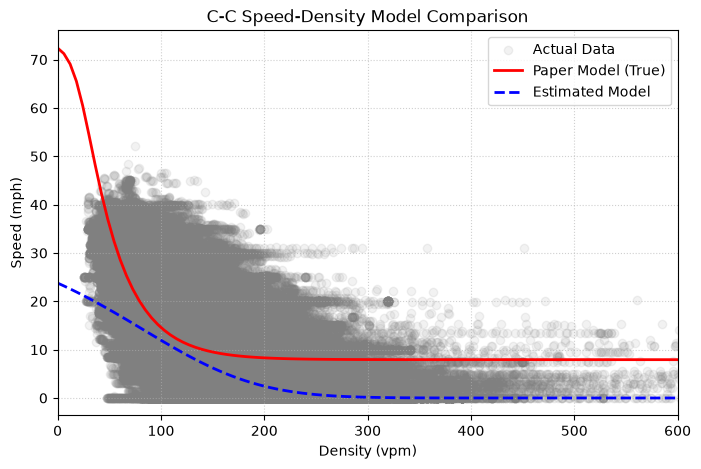

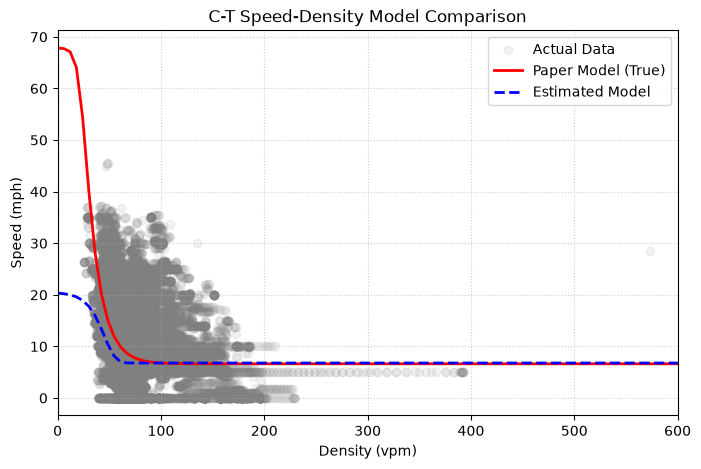

In [ ]:
# 論文等の正解パラメータ
results_cc_true = [7.93, 73.55, 20.4, 8.0387, 0.2309]
results_ct_true = [6.63, 67.87, 22.73, 3.4839, 0.2673]

# 1. C-C 追従の比較描画
plot_model_comparison(
    df=df_density, 
    mode_id=1, 
    params_true=results_cc_true, 
    params_est=results_cc['params'],  # 推定結果のリスト
    mode_name="C-C",
    rho_min=0,
    rho_max=600
)

# 2. C-T 追従の比較描画
plot_model_comparison(
    df=df_density, 
    mode_id=2, 
    params_true=results_ct_true, 
    params_est=results_ct['params'],  # 推定結果のリスト
    mode_name="C-T",
    rho_min=0,
    rho_max=600
)

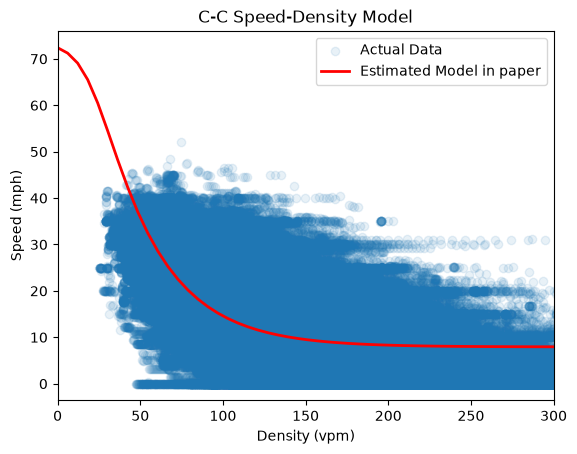

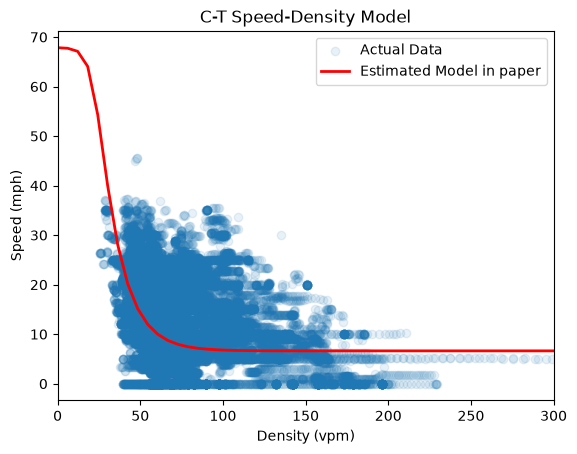

In [ ]:
import matplotlib.pyplot as plt

def plot_model(df, mode_id, params, mode_name):
    ub, uf, rhoc, theta1, theta2 = params

    # 1. 最初に指定した mode_id のデータだけに絞り込む
    df_mode = df[df['mode_id'] == mode_id]
    
    # 描画用データ
    #rho_range = np.linspace(df_mode['Micro_density_vpm'].min(), df_mode['Micro_density_vpm'].max(), 100)
    rho_range = np.linspace(0, 600, 100)
    exp_term = np.exp((rho_range - rhoc) / theta1)
    v_pred = ub + (uf - ub) / ((1 + exp_term) ** theta2)
    
    # 散布図とモデル曲線のプロット
    plt.scatter(df_mode['Micro_density_vpm'], df_mode['v_Vel'], alpha=0.1, label='Actual Data')
    plt.plot(rho_range, v_pred, color='red', linewidth=2, label='Estimated Model in paper')
    plt.xlim(0,300)
    plt.title(f"{mode_name} Speed-Density Model")
    plt.xlabel("Density (vpm)")
    plt.ylabel("Speed (mph)")
    plt.legend()
    plt.show()

results_cc=[7.93, 73.55, 20.4, 8.0387, 0.2309]
results_ct=[6.63, 67.87, 22.73, 3.4839, 0.2673]
# 推定結果を使って実行
plot_model(df_density, 1, results_cc, "C-C")
plot_model(df_density, 2, results_ct, "C-T")

In [ ]:
import matplotlib.pyplot as plt

def plot_model(df, mode_id, params, mode_name):
    ub, uf, rhoc, theta1, theta2 = params

    # 1. 最初に指定した mode_id のデータだけに絞り込む
    df_mode = df[df['mode_id'] == mode_id]
    
    # 描画用データ
    rho_range = np.linspace(df_mode['Micro_density_vpm'].min(), df_mode['Micro_density_vpm'].max(), 100)
    exp_term = np.exp((rho_range - rhoc) / theta1)
    v_pred = ub + (uf - ub) / ((1 + exp_term) ** theta2)
    
    # 散布図とモデル曲線のプロット
    df_mode = df[df['mode_id'] == mode_id]
    plt.scatter(df_mode['Micro_density_vpm'], df_mode['v_Vel'], alpha=0.1, label='Actual Data')
    plt.plot(rho_range, v_pred, color='red', linewidth=2, label='Estimated Model')
    plt.title(f"{mode_name} Speed-Density Model")
    plt.xlabel("Density (vpm)")
    plt.ylabel("Speed (mph)")
    plt.legend()
    plt.show()

# 推定結果を使って実行
plot_model(df_density, 1, results_cc['params'], "C-C")
plot_model(df_density, 2, results_ct['params'], "C-T")

NameError: name 'results_cc' is not defined

c:\Users\AMhetero\.conda\envs\GTA\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36861 (\N{CJK UNIFIED IDEOGRAPH-8FFD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\AMhetero\.conda\envs\GTA\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24467 (\N{CJK UNIFIED IDEOGRAPH-5F93}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


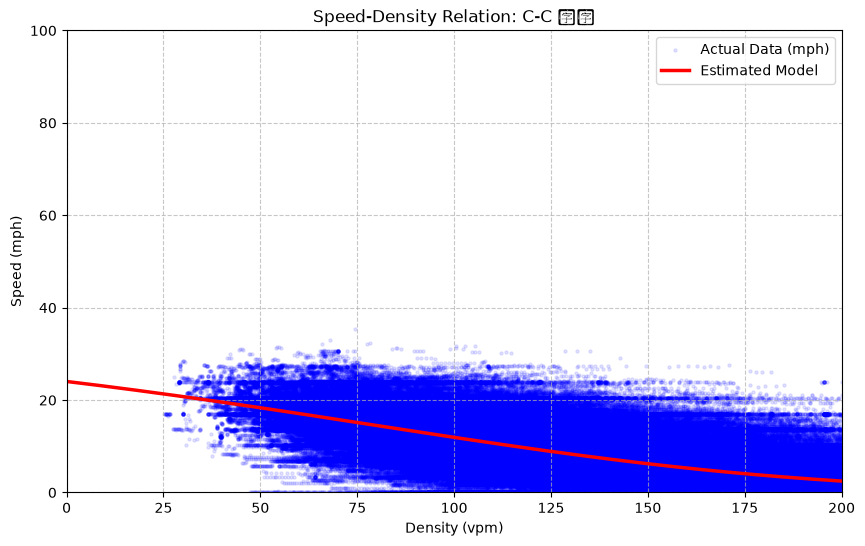

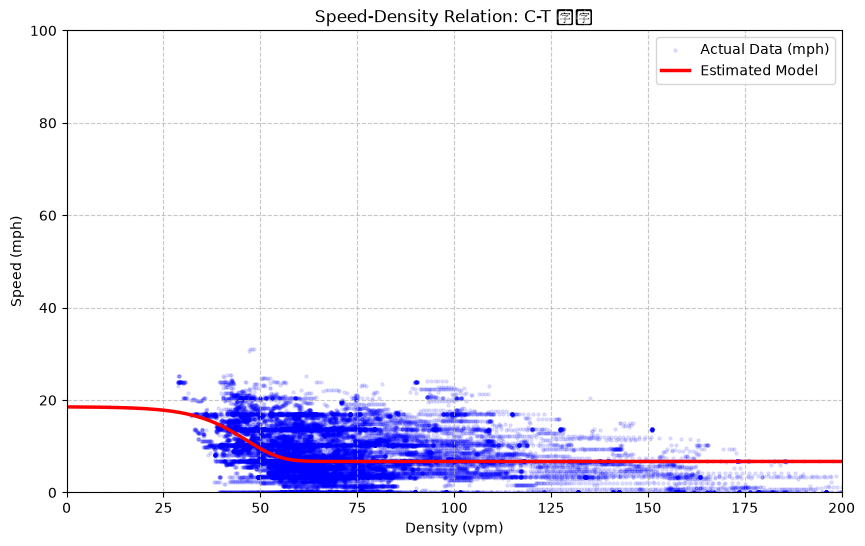

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_speed_density_model(df, mode_id, params, mode_name):
    """
    密度と速度の散布図に、推定モデルの曲線を重ねて表示する
    """
    # パラメータのアンパック
    ub, uf, rhoc, theta1, theta2 = params
    
    # 描画用データ（密度を0から200 vpmの範囲で作成）
    rho_range = np.linspace(0, 200, 200)
    
    # ロジスティックモデルによる予測速度の計算
    exp_term = np.exp(np.clip((rho_range - rhoc) / theta1, -100, 100))
    v_pred = ub + (uf - ub) / ((1 + exp_term) ** theta2)
    
    # 描画設定
    plt.figure(figsize=(10, 6))
    
    # 実測値の散布図 (アルファ値を下げて密度の濃淡が見えるようにする)
    df_mode = df[df['mode_id'] == mode_id]
    plt.scatter(df_mode['Micro_density_vpm'], df_mode['v_Vel'] / 1.4667, 
                alpha=0.1, s=5, label='Actual Data (mph)', color='blue')
    
    # 推定モデルの曲線
    plt.plot(rho_range, v_pred, color='red', linewidth=2.5, label='Estimated Model')
    
    # グラフのラベルや装飾
    plt.title(f"Speed-Density Relation: {mode_name}")
    plt.xlabel("Density (vpm)")
    plt.ylabel("Speed (mph)")
    plt.xlim(0, 200)
    plt.ylim(0, 100)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    plt.show()

# ==========================================
# 実行例
# ==========================================
# results_cc['params'] 等は、先ほど推定した結果の辞書から取得
plot_speed_density_model(df_density, 1, results_cc['params'], "C-C 追従")
plot_speed_density_model(df_density, 2, results_ct['params'], "C-T 追従")


c:\Users\AMhetero\.conda\envs\GTA\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\AMhetero\.conda\envs\GTA\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\AMhetero\.conda\envs\GTA\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\AMhetero\.conda\envs\GTA\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


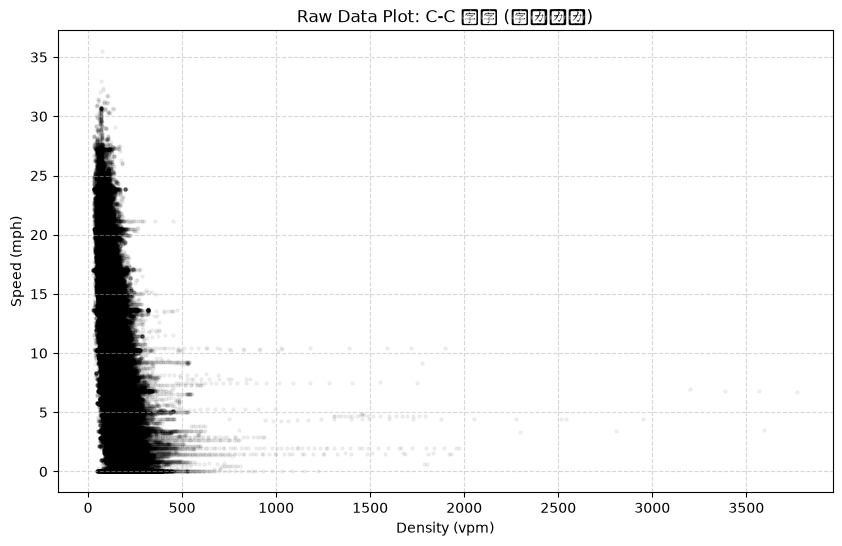

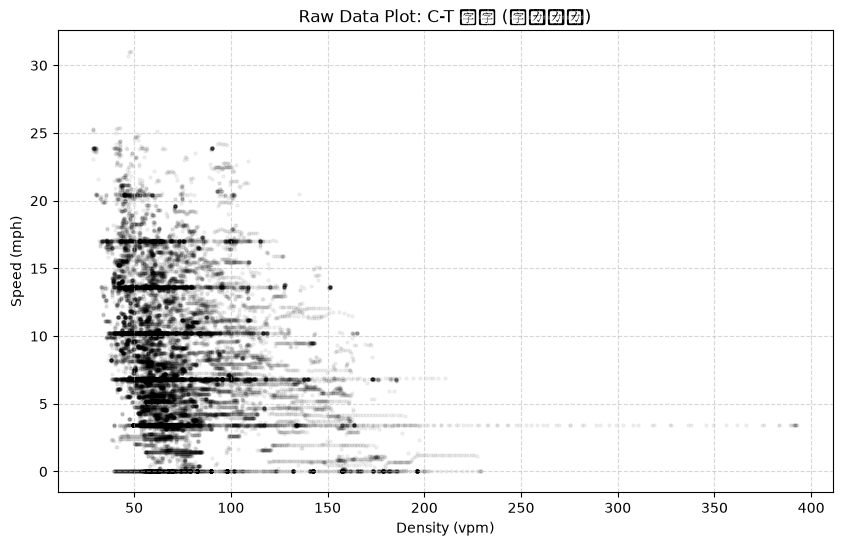

In [ ]:
import matplotlib.pyplot as plt

def plot_raw_data(df, mode_id, mode_name):
    """
    指定したモードの密度(vpm)と速度(mph)の散布図を表示する
    """
    # 該当モードのデータを抽出
    df_mode = df[df['mode_id'] == mode_id].dropna(subset=['Micro_density_vpm', 'v_Vel'])
    
    # 速度を mph に変換 (1 mph = 1.4667 ft/s)
    speed_mph = df_mode['v_Vel'] / 1.4667
    
    # グラフの描画
    plt.figure(figsize=(10, 6))
    plt.scatter(df_mode['Micro_density_vpm'], speed_mph, 
                alpha=0.05, s=5, color='black') # 点が多いため透過度(alpha)を高く設定
    
    plt.title(f"Raw Data Plot: {mode_name}")
    plt.xlabel("Density (vpm)")
    plt.ylabel("Speed (mph)")
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.show()

# ==========================================
# 実行
# ==========================================
# C-C追従とC-T追従それぞれの生データを表示
plot_raw_data(df_density, 1, "C-C 追従 (生データ)")
plot_raw_data(df_density, 2, "C-T 追従 (生データ)")

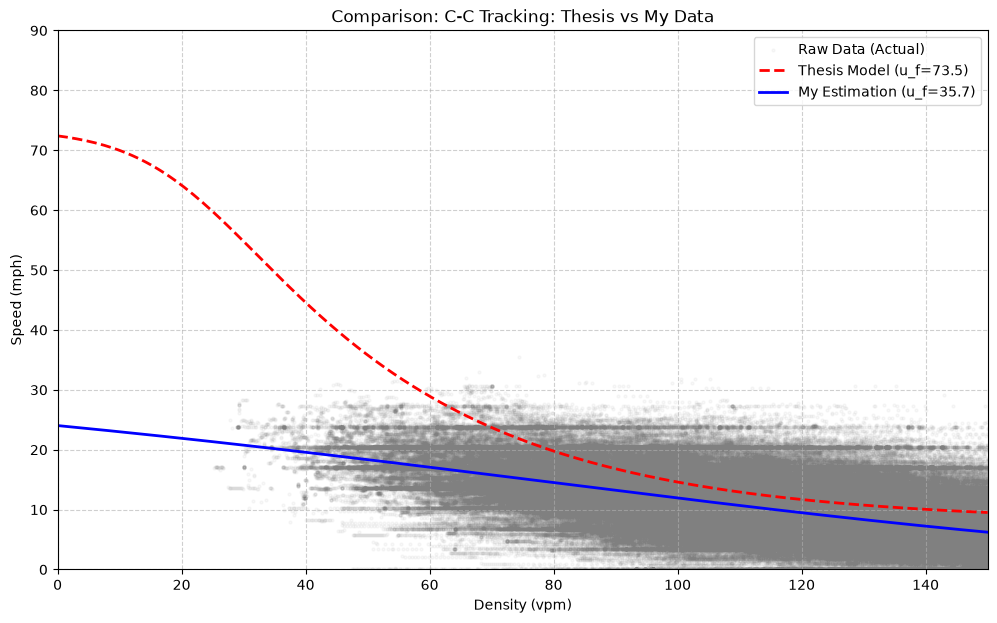

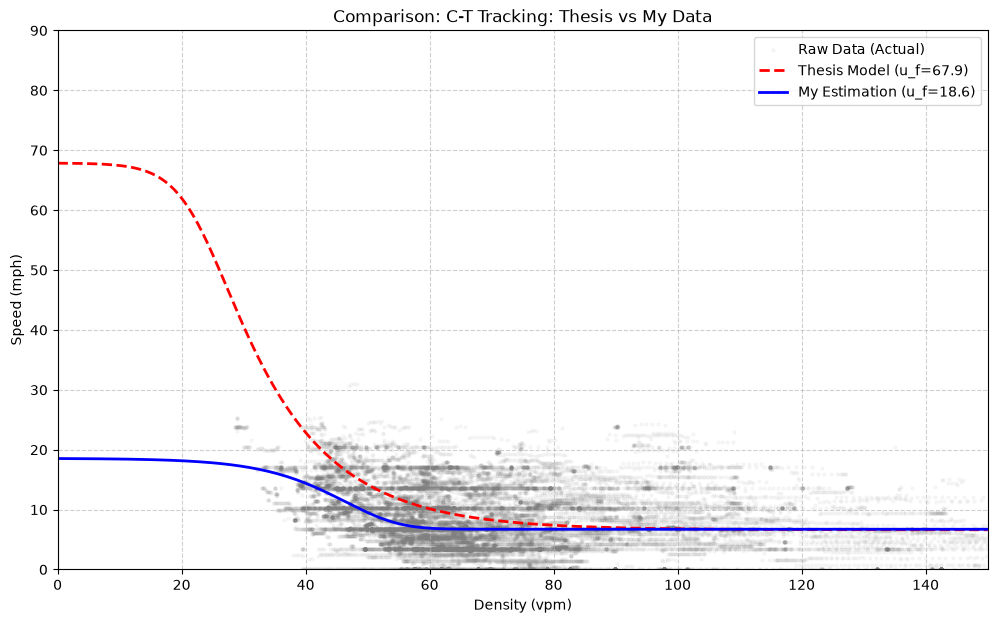

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_comparison_english(df, mode_id, my_params, mode_name):
    # Thesis parameters (Table 4)
    # [ub, uf, rhoc, theta1, theta2]
    thesis_params = {
        1: [7.93, 73.55, 20.40, 8.0387, 0.2309], # Car-Car
        2: [6.63, 67.87, 22.73, 3.4839, 0.2673]  # Car-Truck
    }
    
    # Preparation
    rho_range = np.linspace(0, 150, 200)
    
    def calc_speed(rho, p):
        ub, uf, rhoc, t1, t2 = p
        exp_term = np.exp(np.clip((rho - rhoc) / t1, -100, 100))
        return ub + (uf - ub) / ((1 + exp_term) ** t2)
    
    # Calculate curves
    v_thesis = calc_speed(rho_range, thesis_params[mode_id])
    v_mine = calc_speed(rho_range, my_params)
    
    # Plotting
    plt.figure(figsize=(12, 7))
    
    # 1. Raw data
    df_mode = df[df['mode_id'] == mode_id].dropna(subset=['Micro_density_vpm', 'v_Vel'])
    plt.scatter(df_mode['Micro_density_vpm'], df_mode['v_Vel'] / 1.4667, 
                alpha=0.05, s=5, color='gray', label='Raw Data (Actual)')
    
    # 2. Thesis model
    plt.plot(rho_range, v_thesis, color='red', linestyle='--', linewidth=2, 
             label=f'Thesis Model (u_f={thesis_params[mode_id][1]:.1f})')
    
    # 3. My estimation
    plt.plot(rho_range, v_mine, color='blue', linewidth=2, 
             label=f'My Estimation (u_f={my_params[1]:.1f})')
    
    plt.title(f"Comparison: {mode_name}")
    plt.xlabel("Density (vpm)")
    plt.ylabel("Speed (mph)")
    plt.xlim(0, 150)
    plt.ylim(0, 90)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# ==========================================
# Execution
# ==========================================
plot_comparison_english(df_density, 1, results_cc['params'], "C-C Tracking: Thesis vs My Data")
plot_comparison_english(df_density, 2, results_ct['params'], "C-T Tracking: Thesis vs My Data")


 モデル推定開始 (ISRES): Car-Car (C-C) (mode_id=1)


C:\Users\AMhetero\AppData\Local\Temp\ipykernel_21176\1653599708.py:39: RuntimeWarning: overflow encountered in power
  denom = (1 + exp_term) ** theta2



--- 推定結果 ---
u_b: 0.0014 mph, u_f: 36.1449 mph, rho_c: 199.8667 vpm
theta1: 90.6948, theta2: 3.8632
テストデータ MAE: 3.2470 mph

 モデル推定開始 (ISRES): Car-Truck (C-T) (mode_id=2)


C:\Users\AMhetero\AppData\Local\Temp\ipykernel_21176\1653599708.py:39: RuntimeWarning: overflow encountered in power
  denom = (1 + exp_term) ** theta2



--- 推定結果 ---
u_b: 6.7501 mph, u_f: 18.3722 mph, rho_c: 62.4003 vpm
theta1: 7.7382, theta2: 7.9411
テストデータ MAE: 3.8316 mph

 モデル推定開始 (ISRES): Truck-Truck (T-T) (mode_id=3)


C:\Users\AMhetero\AppData\Local\Temp\ipykernel_21176\1653599708.py:39: RuntimeWarning: overflow encountered in power
  denom = (1 + exp_term) ** theta2



--- 推定結果 ---
u_b: 0.0038 mph, u_f: 15.0300 mph, rho_c: 199.3899 vpm
theta1: 74.6870, theta2: 2.7263
テストデータ MAE: 3.3294 mph

 モデル推定開始 (ISRES): Truck-Car (T-C) (mode_id=4)


C:\Users\AMhetero\AppData\Local\Temp\ipykernel_21176\1653599708.py:39: RuntimeWarning: overflow encountered in power
  denom = (1 + exp_term) ** theta2



--- 推定結果 ---
u_b: 6.7083 mph, u_f: 14.1546 mph, rho_c: 53.2814 vpm
theta1: 2.8587, theta2: 9.7039
テストデータ MAE: 2.7698 mph


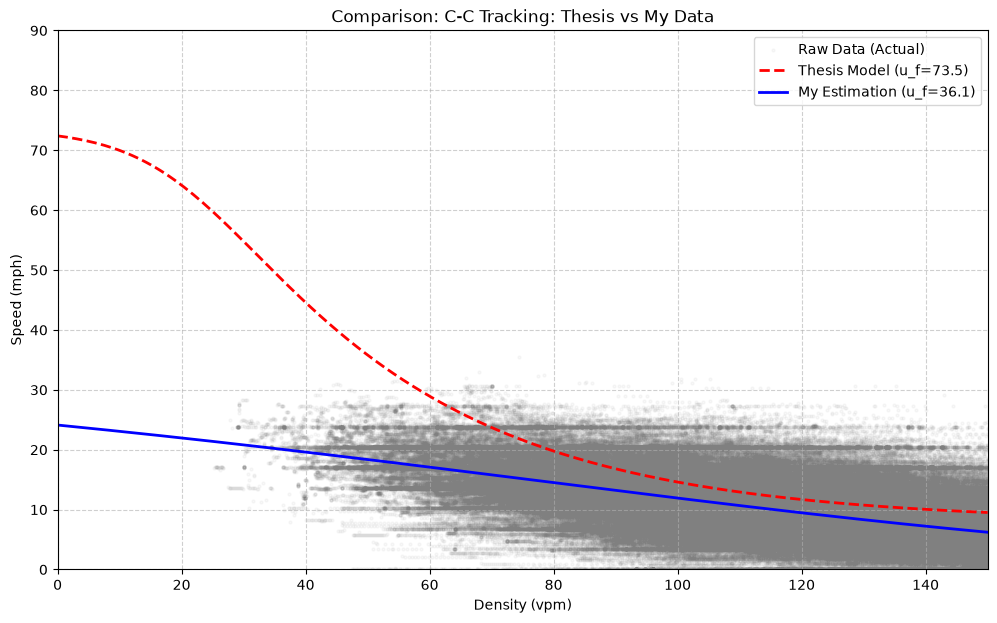

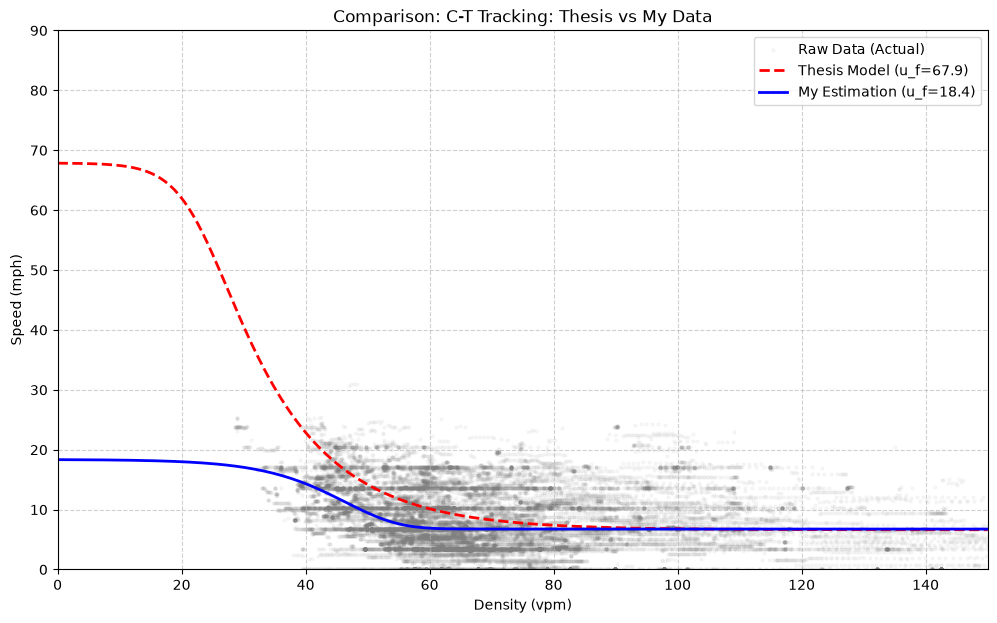

KeyError: 3

In [ ]:
# 実行部分を拡張して4つのモードすべてを個別に処理します
# 既存の fit_logistic_model_nlopt_isres 関数はそのまま使用可能です

# それぞれのモードに対して推定を実行
# mode_id はデータセットに合わせて適宜調整してください
results_cc = fit_logistic_model_nlopt_isres(df_density, mode_id=1, mode_name="Car-Car (C-C)")
results_ct = fit_logistic_model_nlopt_isres(df_density, mode_id=2, mode_name="Car-Truck (C-T)")
results_tt = fit_logistic_model_nlopt_isres(df_density, mode_id=3, mode_name="Truck-Truck (T-T)")
results_tc = fit_logistic_model_nlopt_isres(df_density, mode_id=4, mode_name="Truck-Car (T-C)")

# グラフ比較の実行 (各モードごとに生成)
plot_comparison_english(df_density, 1, results_cc['params'], "C-C Tracking: Thesis vs My Data")
plot_comparison_english(df_density, 2, results_ct['params'], "C-T Tracking: Thesis vs My Data")
plot_comparison_english(df_density, 3, results_tt['params'], "T-T Tracking: Thesis vs My Data")
plot_comparison_english(df_density, 4, results_tc['params'], "T-C Tracking: Thesis vs My Data")